In [1]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import xesmf as xe
from pathlib import Path 

# Regrid RDA ERA5 to Desired Resolutions for Training


In [2]:
### from Maria Molina 2025

def edges_from_centers(c, clip=None):
    c = np.asarray(c); d = np.diff(c)
    e = np.concatenate(([c[0]-d[0]/2], (c[:-1]+c[1:])/2, [c[-1]+d[0]/2]))
    return np.clip(e, *clip) if clip is not None else e

def standardize_ds(ds_in):
    ds_in = ds_in.rename(latitude="lat", longitude="lon")
    ds_in = ds_in.assign_coords(lon=(ds_in.lon % 360)).sortby("lon").sortby("lat")
    return ds_in

def build_regridder_with_poles(ds_in, dlat=1, method="conservative_normed", filename=None, reuse=False):
   # ds = standardize_ds(ds_in) 

    # --- source grid + clipped bounds (avoid ±90±Δ/2) ---
    lat_in, lon_in = ds_in.lat.values, ds_in.lon.values
    src = xr.Dataset(coords=dict(
        lat=("lat", lat_in), lon=("lon", lon_in),
        lat_b=("lat_b", edges_from_centers(lat_in, clip=(-90, 90))),
        lon_b=("lon_b", edges_from_centers(lon_in, clip=(0, 360)))
    ))

    # --- destination grid: 240 x 121 (includes poles) ---
    lat_out = np.linspace(-90, 90, int(round(180/dlat))+1)   # 121
    lon_out = np.arange(0, 360, dlat)                        # 240
    dst = xr.Dataset(coords=dict(
        lat=("lat", lat_out), lon=("lon", lon_out),
        lat_b=("lat_b", edges_from_centers(lat_out, clip=(-90, 90))),
        lon_b=("lon_b", edges_from_centers(lon_out, clip=(0, 360)))
    ))

    R = xe.Regridder(src, dst, method,
                     periodic=True, filename=filename,
                     reuse_weights=reuse, ignore_degenerate=True)
    return R

In [3]:
# pressure fields
# /glade/campaign/collections/rda/data/d633001/e5.moda.an.pl/{year}/
# 1000 850 700 500 250 100 50
# temperature [ta, K], 
# specific humidity [hus, kg/kg], 
# eastward wind component [ua, m/s], 
# northward wind component [va, m/s]

# Surface fields
# /glade/campaign/collections/rda/data/d633001/e5.moda.an.sfc/{year}/
# surface pressure [ps, Pa] and/or sea-level pressure [psl, Pa], sp
# surface temperature [ts, K] (skin temp. over land or sea ice, SST over ocean, whatever your model uses in 
# grid cells with mixed surface types), skt
# 2 m air temperature [tas, K], 2t
# 2 m specific humidity [huss, kg/kg], 2d???
# 10 m eastward wind [uas, m/s], 10u
# 10 m northward wind [vas, m/s], 10v

# mean flux
# /glade/campaign/collections/rda/data/d633001/e5.moda.fc.sfc.meanflux/{year}/
# Surface precipitation rate [pr, kg/(m^2 s)], includes both liquid and frozen - this should be computed as a 
# time-averaged rate over the month, rather than from a month of daily snapshots, to avoid adding excessive sampling noise.
# mtpr
# e5.moda.fc.sfc.meanflux.235_055_mtpr.ll025sc.*.nc

# total precip
# e5.moda.fc.sfc.accumu.128_228_tp.ll025sc.*.nc in m
# /glade/campaign/collections/rda/data/d633001/e5.moda.fc.sfc.accumu/{year}/
# m (of water equivalent per day)
# https://confluence.ecmwf.int/pages/viewpage.action?pageId=197702790

In [4]:
variables = {
    'sp':  { 'vertical': 'surface', 'levels': [], "file_mod": ".moda.an.sfc", "main_variable": "SP" },
    'skt': { 'vertical': 'surface', 'levels': [], "file_mod": ".moda.an.sfc", "main_variable": "SKT" },
    '2t': { 'vertical': 'surface', 'levels': [], "file_mod": ".moda.an.sfc", "main_variable": "VAR_2T" },
    '2d':  { 'vertical': 'surface', 'levels': [], "file_mod": ".moda.an.sfc", "main_variable": "VAR_2D" },
    '10u': { 'vertical': 'surface', 'levels': [], "file_mod": ".moda.an.sfc", "main_variable": "VAR_10U" },
    '10v': { 'vertical': 'surface', 'levels': [], "file_mod": ".moda.an.sfc", "main_variable": "VAR_10V" },
    'sstk': { 'vertical': 'surface', 'levels': [], "file_mod": ".moda.an.sfc", "main_variable": "SSTK" },
    'ci':  { 'vertical': 'surface', 'levels': [], "file_mod": ".moda.an.sfc", "main_variable": "CI" },
    'mtpr': { 'vertical': 'surface', 'levels': [], "file_mod": ".moda.fc.sfc.meanflux", "main_variable": "MTPR" },
    'msl': { 'vertical': 'surface', 'levels': [], "file_mod": ".moda.an.sfc", "main_variable": "MSL" },
    't':  { 'vertical': 'pressure', 'levels': [1000., 850., 700., 500.,  250., 100.,  50.], "file_mod": ".moda.an.pl", "main_variable": "T" },
    'q':  { 'vertical': 'pressure', 'levels': [1000., 850., 700., 500.,  250., 100.,  50.], "file_mod": ".moda.an.pl", "main_variable": "Q" },
    'u':  { 'vertical': 'pressure', 'levels': [1000., 850., 700., 500.,  250., 100.,  50.], "file_mod": ".moda.an.pl", "main_variable": "U" },
    'v':  { 'vertical': 'pressure', 'levels': [1000., 850., 700., 500.,  250., 100.,  50.], "file_mod": ".moda.an.pl", "main_variable": "V" },
    'z': { 'vertical': 'pressure', 'levels':  [ 500. ], "file_mod": ".moda.an.pl", "main_variable": "Z" },
}
year = np.arange(1950, 2023, 1)

In [5]:
nominal_res = 5.0
overwrite_regridder = True 

for var in variables.keys():
    print(f"Starting {var}")
    orig_filename = f"/glade/work/khall/ERA5/prod/ERA5_{variables[var]['main_variable']}_195001-202212_native0p25x0p25.nc"

    if not Path(orig_filename).is_file():
        print(f"    pre-1979 files: /glade/campaign/collections/rda/data/d633005/e5p{variables[var]['file_mod']}/*/*_{var}.*.nc") 

        pre_1979_ds = xr.open_mfdataset(f"/glade/campaign/collections/rda/data/d633005/e5p{variables[var]['file_mod']}/*/*_{var}.*.nc")
        print(f"    post-1979 files: /glade/campaign/collections/rda/data/d633001/e5{variables[var]['file_mod']}/*/*_{var}.*.nc")

        post_1979_ds = xr.open_mfdataset(f"/glade/campaign/collections/rda/data/d633001/e5{variables[var]['file_mod']}/*/*_{var}.*.nc")
        ds_1950_2022 = xr.concat([pre_1979_ds, post_1979_ds], 'time')
        print("    opened files (dask) ")
    
        if variables[var]['vertical'] == 'pressure':
            ds_1950_2022 = ds_1950_2022.sel(level=variables[var]['levels'])

    else:
        ds_1950_2022 = xr.open_dataset(orig_filename).load()

    print("    loaded files to RAM ")

    if not Path(orig_filename).is_file():
        ds_1950_2022 = standardize_ds(ds_1950_2022).load()
        ds_1950_2022.to_netcdf(orig_filename)
        print('    saved original file')

    mask = xr.where(~np.isnan(ds_1950_2022[variables[var]["main_variable"]].isel(time=0, drop=True)), 1, 0)
    print("    got mask ")

    regridding_weights = f"/glade/work/khall/ERA5/dev/conservative_normed_regridder_with_poles_{var}_res{nominal_res}.nc"
    ds_1950_2022['mask'] = mask
    regridder = build_regridder_with_poles(
        ds_1950_2022,
        dlat=nominal_res, 
        method="conservative_normed" if var != 'mtpr' else 'conservative',
        filename=None if (not Path(regridding_weights).is_file()) or overwrite_regridder else regridding_weights,
        reuse=Path(regridding_weights).is_file() and not overwrite_regridder
    )

    if not Path(regridding_weights).is_file() or overwrite_regridder:
        regridder.to_netcdf(regridding_weights)
    print('    built regridder')

    regridded_ds = regridder(ds_1950_2022)
    print('    regridding finished')

    out_filename = f"/glade/work/khall/ERA5/prod/ERA5_{variables[var]['main_variable']}_195001-202212_{str(nominal_res).replace('.','p')}x{str(nominal_res).replace('.','p')}.nc"
    regridded_ds.to_netcdf(out_filename)
    print('    file saved to ' + out_filename)




Starting sp
    loaded files to RAM 
    got mask 
    built regridder
    regridding finished
    file saved to /glade/work/khall/ERA5/prod/ERA5_SP_195001-202212_5p0x5p0.nc
Starting skt
    loaded files to RAM 
    got mask 
    built regridder
    regridding finished
    file saved to /glade/work/khall/ERA5/prod/ERA5_SKT_195001-202212_5p0x5p0.nc
Starting 2t
    loaded files to RAM 
    got mask 
    built regridder
    regridding finished
    file saved to /glade/work/khall/ERA5/prod/ERA5_VAR_2T_195001-202212_5p0x5p0.nc
Starting 2d
    loaded files to RAM 
    got mask 
    built regridder
    regridding finished
    file saved to /glade/work/khall/ERA5/prod/ERA5_VAR_2D_195001-202212_5p0x5p0.nc
Starting 10u
    loaded files to RAM 
    got mask 
    built regridder
    regridding finished
    file saved to /glade/work/khall/ERA5/prod/ERA5_VAR_10U_195001-202212_5p0x5p0.nc
Starting 10v
    loaded files to RAM 
    got mask 
    built regridder
    regridding finished
    file saved to 

# Check that They Look Reasonable against the original data

opened nominal res
opened orig


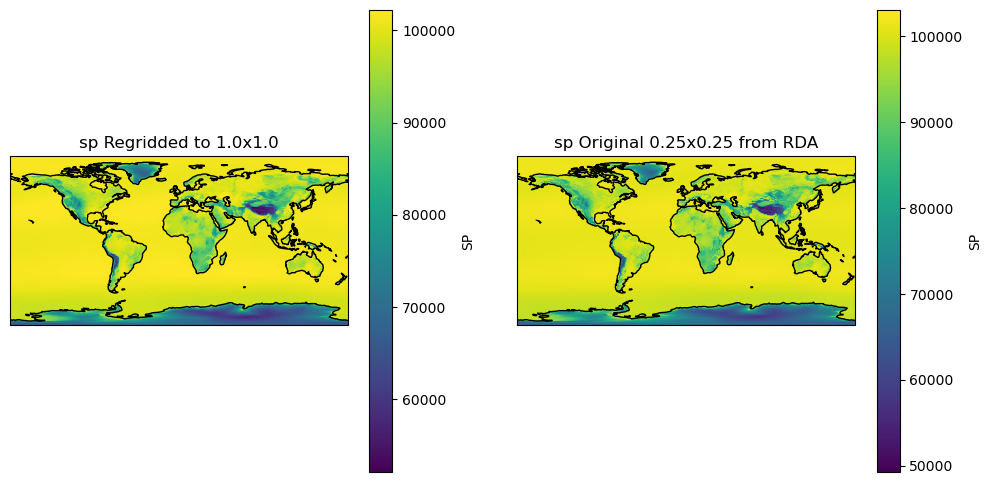

         Nominal      Original
means:  96608.555 96652.58
mins:  51011.266 48057.195
maxs:  104272.95 104762.89
stddevs:  9572.693 9562.778
opened nominal res
opened orig


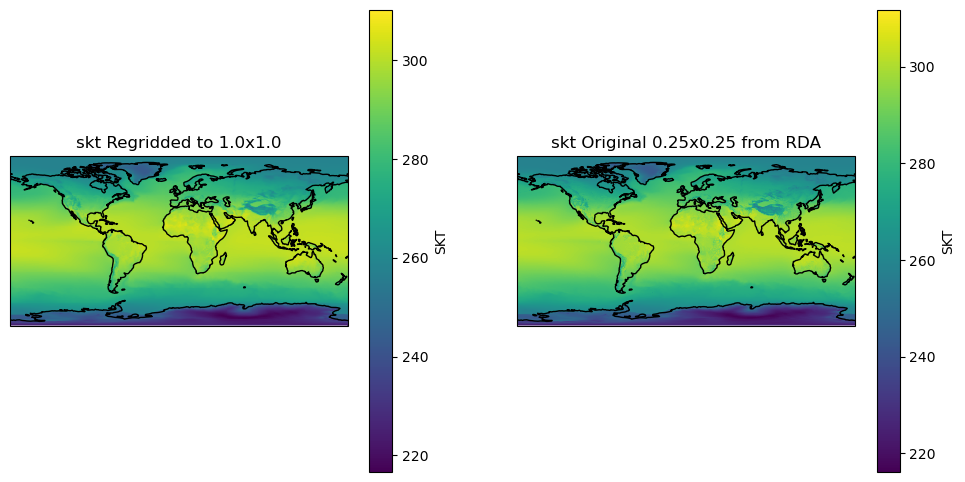

         Nominal      Original
means:  278.44095 278.59198
mins:  196.54861 195.9108
maxs:  318.10437 319.20642
stddevs:  22.257067 22.17049
opened nominal res
opened orig


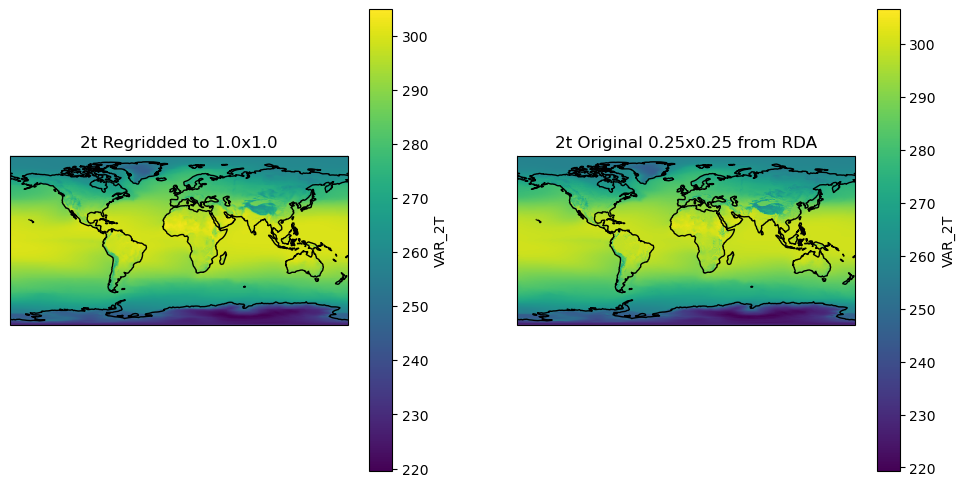

         Nominal      Original
means:  278.05347 278.197
mins:  201.12946 199.93073
maxs:  315.07498 315.4784
stddevs:  21.24937 21.155182
opened nominal res
opened orig


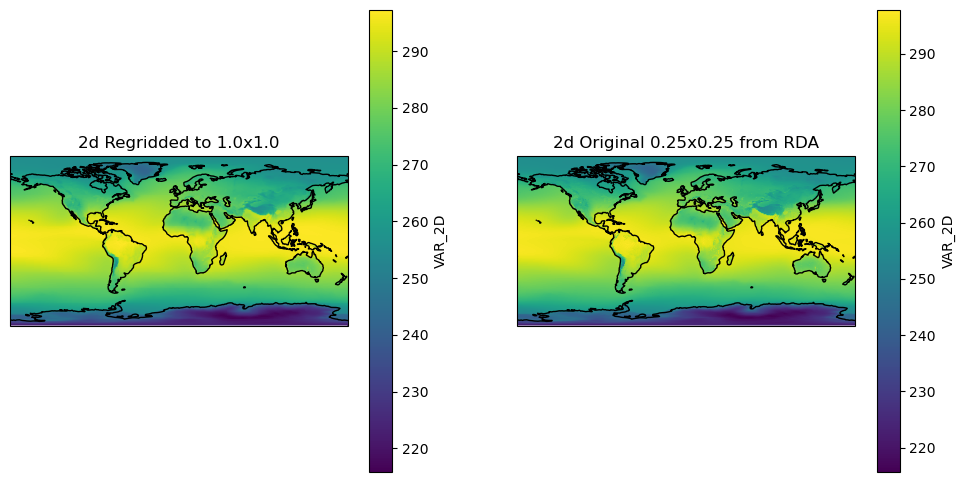

         Nominal      Original
means:  273.5567 273.69656
mins:  197.6106 196.53801
maxs:  302.336 302.54248
stddevs:  20.694069 20.600206
opened nominal res
opened orig


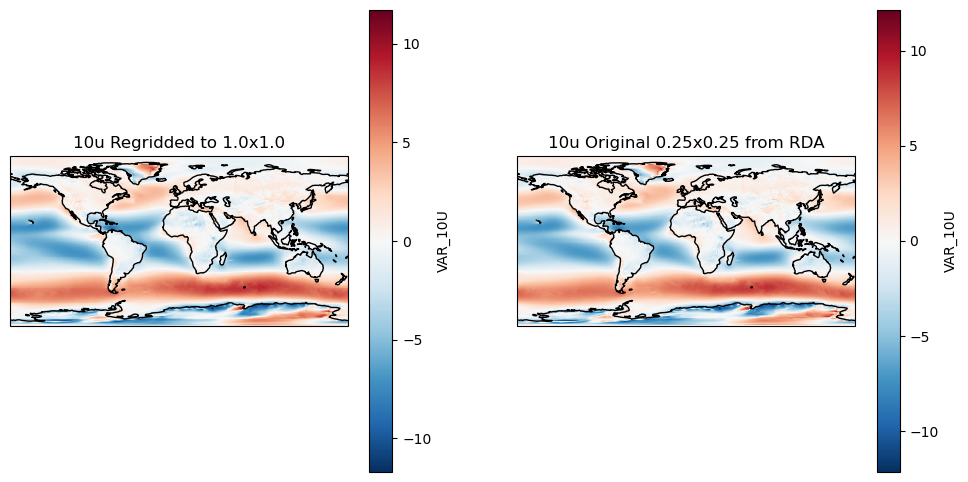

         Nominal      Original
means:  -0.049213134 -0.04845668
mins:  -17.755066 -20.344284
maxs:  13.767947 16.193924
stddevs:  3.8504572 3.870944
opened nominal res
opened orig


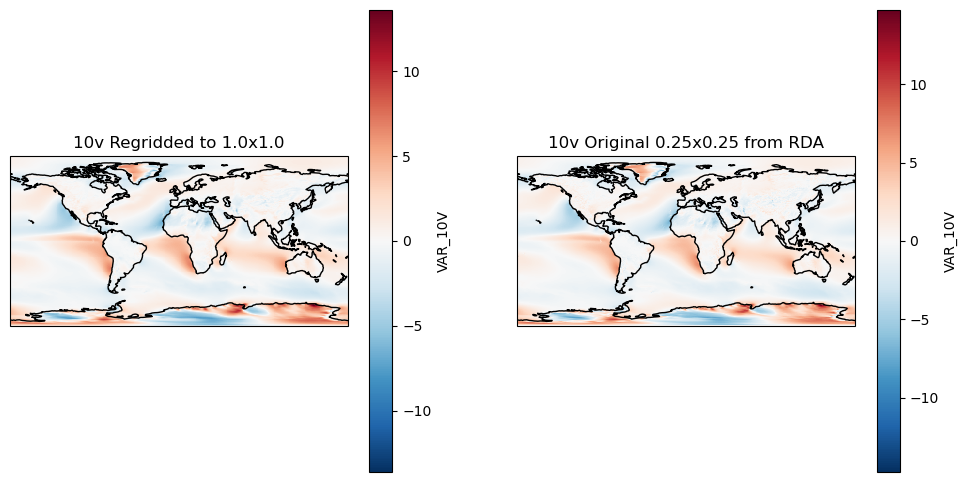

         Nominal      Original
means:  0.18456031 0.18548577
mins:  -15.793652 -16.109695
maxs:  18.588211 20.362217
stddevs:  2.464299 2.4828608
opened nominal res
opened orig


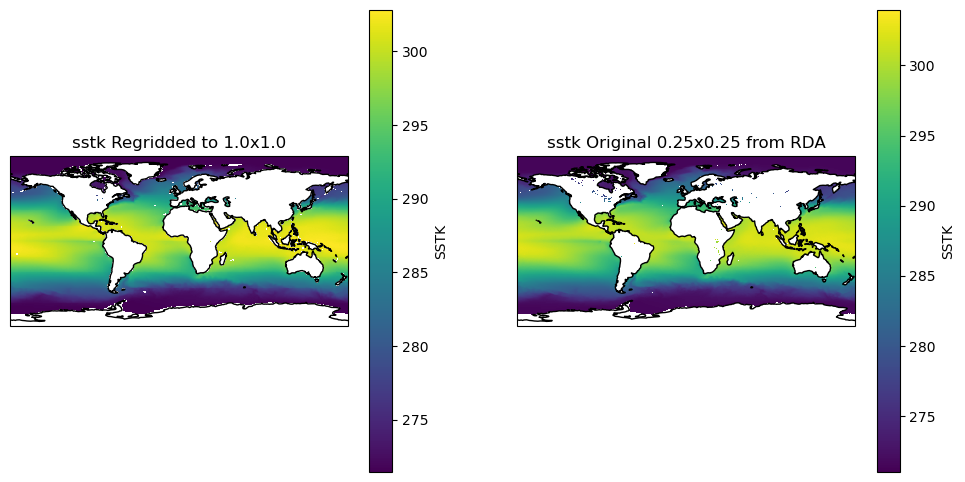

         Nominal      Original
means:  286.86176 286.7646
mins:  271.18518 269.12866
maxs:  309.19757 309.6814
stddevs:  11.561968 11.624104
opened nominal res
opened orig


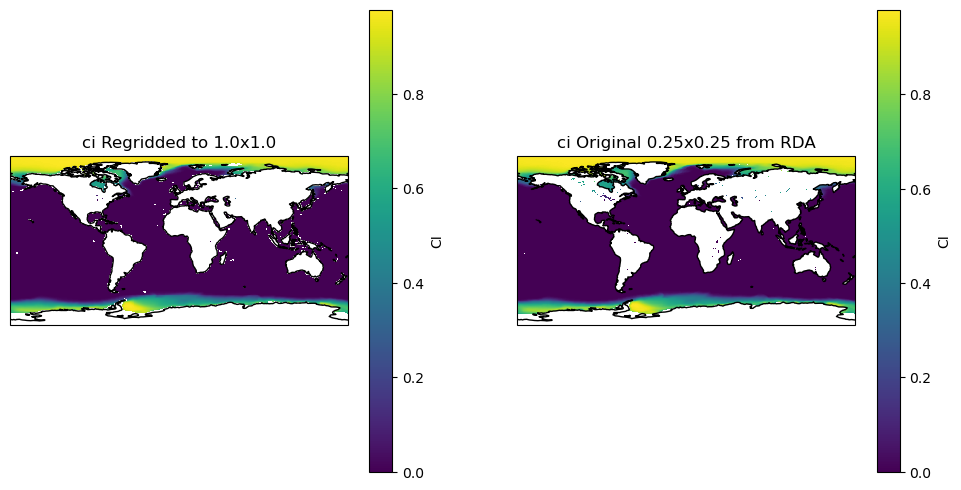

         Nominal      Original
means:  0.16815372 0.17306028
mins:  0.0 0.0
maxs:  1.0 1.0
stddevs:  0.35260737 0.35564083
opened nominal res
opened orig


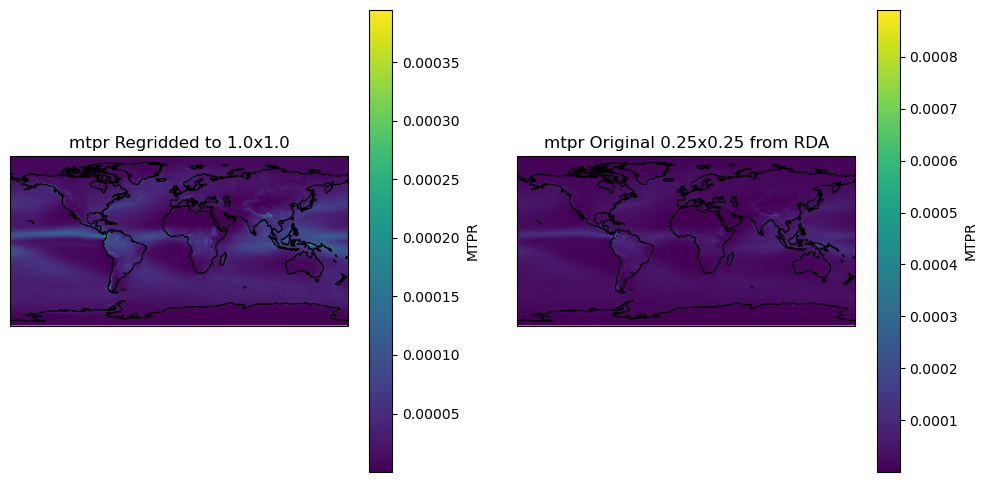

         Nominal      Original
means:  2.7356908e-05 2.744943e-05
mins:  0.0 0.0
maxs:  0.000797682 0.0017976463
stddevs:  3.1832755e-05 3.263572e-05
opened nominal res
opened orig


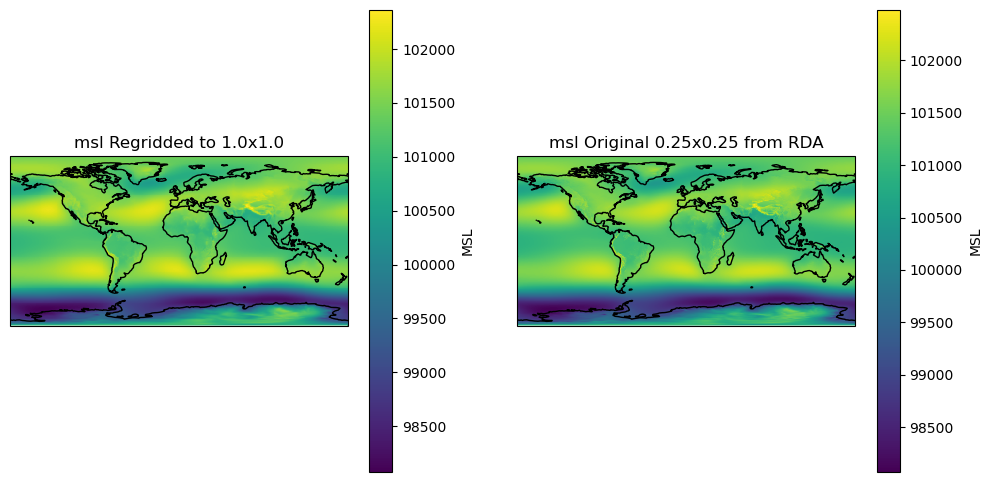

         Nominal      Original
means:  100966.82 100971.79
mins:  95884.234 95879.25
maxs:  104754.08 104965.125
stddevs:  1058.6595 1060.4205
opened nominal res
opened orig


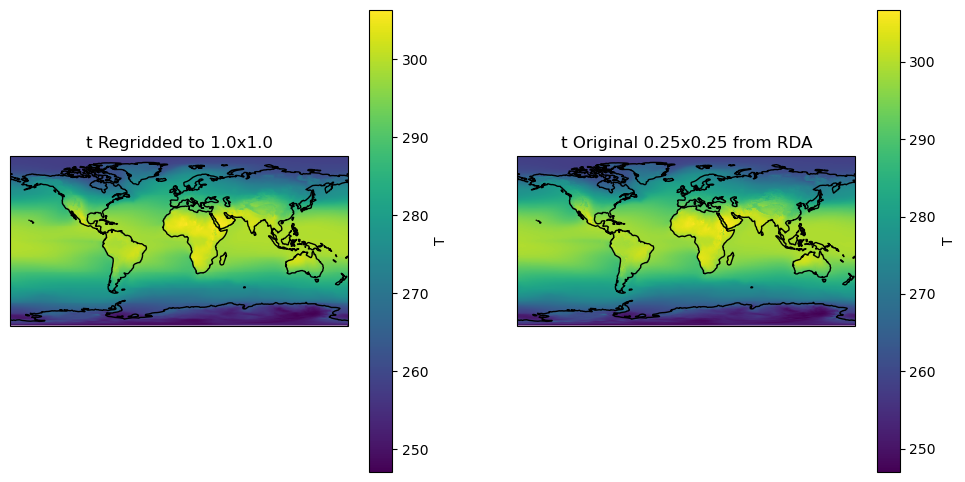

         Nominal      Original
means:  280.6447 280.7525
mins:  224.9771 222.46165
maxs:  317.17276 318.81335
stddevs:  17.057142 17.00131


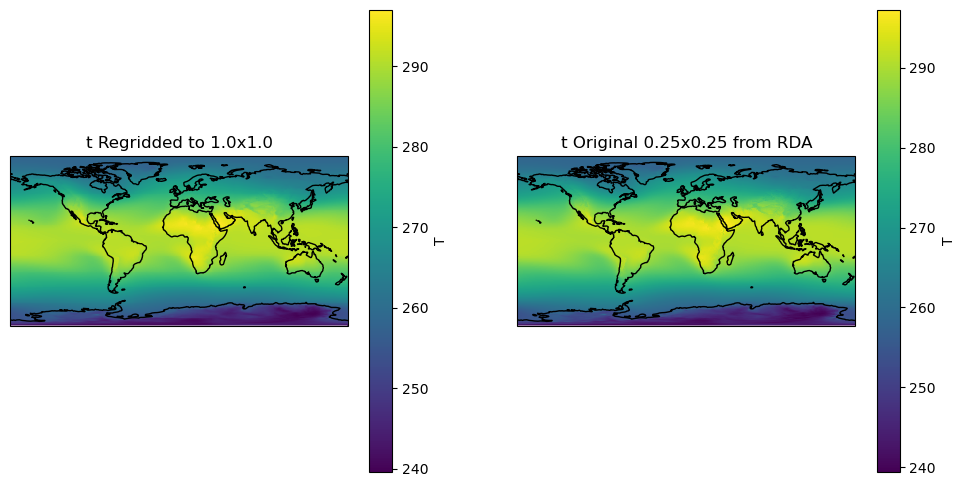

         Nominal      Original
means:  274.259 274.35446
mins:  223.85558 223.3051
maxs:  307.5843 308.24286
stddevs:  15.302033 15.24429


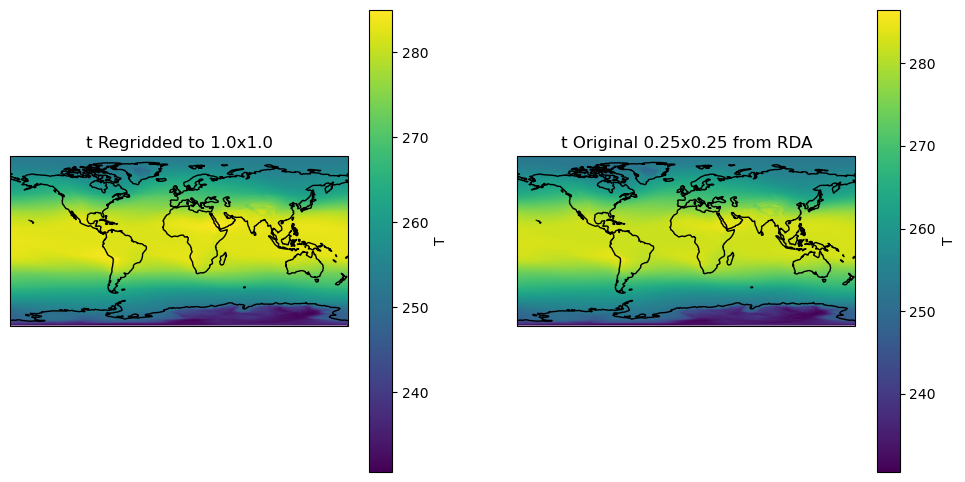

         Nominal      Original
means:  267.10056 267.189
mins:  215.57455 215.122
maxs:  294.0601 294.44135
stddevs:  14.489584 14.421476


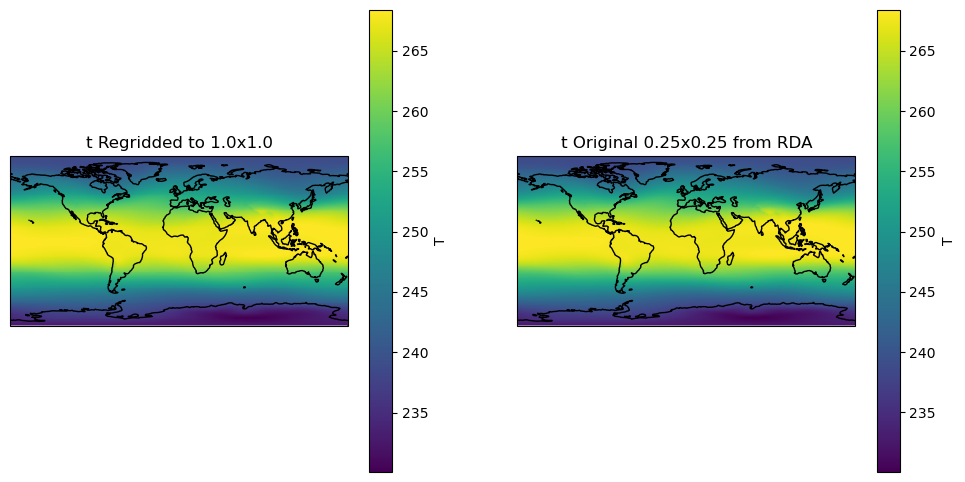

         Nominal      Original
means:  252.68916 252.76448
mins:  220.23874 220.20952


In [ ]:
import cartopy.crs as ccrs 
import matplotlib.pyplot as plt 
nominal_res = 1.0
for var in variables.keys():
    ds_res = xr.open_dataset(f"/glade/work/khall/ERA5/prod/ERA5_{variables[var]['main_variable']}_195001-202212_{str(nominal_res).replace('.','p')}x{str(nominal_res).replace('.','p')}.nc") 
    print('opened nominal res')

    ds_orig = xr.open_dataset(f"/glade/work/khall/ERA5/prod/ERA5_{variables[var]['main_variable']}_195001-202212_native0p25x0p25.nc") 
    print('opened orig')
    
    if variables[var]['vertical'] == 'pressure': 
        for plev in ds_res.level.values:
            fig, ax = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': ccrs.PlateCarree()} , figsize=(12, 6))
        
            ds_res[variables[var]['main_variable']].sel(level=plev).mean('time').plot(ax=ax[0])
            ax[0].coastlines()
            ax[0].set_title(f"{var} Regridded to {nominal_res}x{nominal_res}")
        
            ds_orig[variables[var]['main_variable']].sel(level=plev).mean('time').plot(ax=ax[1])
            ax[1].coastlines()
            ax[1].set_title(f"{var} Original 0.25x0.25 from RDA")
            plt.show()
        
            print("         Nominal      Original")
            print("means: ", ds_res[variables[var]['main_variable']].sel(level=plev).mean().values, ds_orig[variables[var]['main_variable']].sel(level=plev).mean().values) 
            print("mins: ", ds_res[variables[var]['main_variable']].sel(level=plev).min().values, ds_orig[variables[var]['main_variable']].sel(level=plev).min().values) 
            print("maxs: ", ds_res[variables[var]['main_variable']].sel(level=plev).max().values, ds_orig[variables[var]['main_variable']].sel(level=plev).max().values) 
            print("stddevs: ", ds_res[variables[var]['main_variable']].sel(level=plev).std().values, ds_orig[variables[var]['main_variable']].sel(level=plev).std().values) 
    else:
        fig, ax = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': ccrs.PlateCarree()} , figsize=(12, 6))
    
        ds_res[variables[var]['main_variable']].mean('time').plot(ax=ax[0])
        ax[0].coastlines()
        ax[0].set_title(f"{var} Regridded to {nominal_res}x{nominal_res}")
    
        ds_orig[variables[var]['main_variable']].mean('time').plot(ax=ax[1])
        ax[1].coastlines()
        ax[1].set_title(f"{var} Original 0.25x0.25 from RDA")
        plt.show()
    
        print("         Nominal      Original")
        print("means: ", ds_res[variables[var]['main_variable']].mean().values, ds_orig[variables[var]['main_variable']].mean().values) 
        print("mins: ", ds_res[variables[var]['main_variable']].min().values, ds_orig[variables[var]['main_variable']].min().values) 
        print("maxs: ", ds_res[variables[var]['main_variable']].max().values, ds_orig[variables[var]['main_variable']].max().values) 
        print("stddevs: ", ds_res[variables[var]['main_variable']].std().values, ds_orig[variables[var]['main_variable']].std().values) 



# Regrid Invariant RDA ERA5 Files

In [8]:
invariant_variables = {
    'sdor': "e5.oper.invariant.128_160_sdor.ll025sc.1979010100_1979010100.nc",
    'anor': "e5.oper.invariant.128_162_anor.ll025sc.1979010100_1979010100.nc",
    'isor': "e5.oper.invariant.128_161_isor.ll025sc.1979010100_1979010100.nc",
    'slor': "e5.oper.invariant.128_163_slor.ll025sc.1979010100_1979010100.nc",
    'lsm': "e5.oper.invariant.128_172_lsm.ll025sc.1979010100_1979010100.nc"
}
nominal_res = 1

for var in invariant_variables.keys():
    ds = xr.open_dataset(f'/glade/campaign/collections/rda/data/d633000/e5.oper.invariant/197901/{invariant_variables[var]}').mean('time')
    ds = standardize_ds(ds).load()

    mask = xr.where(~np.isnan(ds[var.upper()]), 1, 0)
    ds['mask'] = mask

    regridding_weights = f"/glade/work/khall/ERA5/dev/conservative_normed_regridder_with_poles_{var}_res{nominal_res}.nc"
    fn = build_regridder_with_poles(
        ds, 
        dlat=nominal_res, 
        method="conservative_normed", 
        filename=None if (not Path(regridding_weights).is_file()) or overwrite_regridder else regridding_weights,
        reuse=Path(regridding_weights).is_file() and not overwrite_regridder
    )
    if not Path(regridding_weights).is_file() or overwrite_regridder:
        regridder.to_netcdf(regridding_weights)

    regridded_ds = regridder(ds)

    out_filename = f"/glade/work/khall/ERA5/prod/ERA5_{var.upper()}_195001-202212_{str(nominal_res).replace('.','p')}x{str(nominal_res).replace('.','p')}.nc"
    regridded_ds.to_netcdf(out_filename)
    print(var + '    file saved to ' + out_filename)
